# LSTM Training

## Loading dataset and property labels

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence
from tqdm import trange, tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.metrics import f1_score
import time
import os
from utilities import load_pickle

# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in use: {device}")

def load_trace_data(csv_file, property_file, prefix_extraction=True, min_prefix_length=2, max_trace_length=50, return_case_ids=False):
    df = pd.read_csv(csv_file)
    df['start_time'] = pd.to_datetime(df['start_time'])
    df = df.sort_values(['case:concept:name', 'start_time'])
    property_dict = load_pickle(property_file)
    traces, labels = [], []
    case_ids = [] if return_case_ids else None
    activity_to_idx = {}
    idx_counter = 1

    for case_id, group in tqdm(df.groupby('case:concept:name'), desc="Extracting prefixes"):
        submitted_time = None
        sent_time = None
        seq = []
        prev_time = None
        prop_values = property_dict[case_id]

        for _, row in group.iterrows():
            event_name = row['concept:name']
            timestamp = row['start_time']

            if event_name not in activity_to_idx:
                activity_to_idx[event_name] = idx_counter
                idx_counter += 1

            delta = 0 if prev_time is None else (timestamp - prev_time).total_seconds()
            prev_time = timestamp
            seq.append([activity_to_idx[event_name], delta])

            if prefix_extraction and len(seq) >= min_prefix_length:
                diff_time = (sent_time - submitted_time).total_seconds() if (submitted_time and sent_time) else -1
               
                traces.append(torch.tensor(seq[:], dtype=torch.float32))
                labels.append(prop_values)
                if return_case_ids:
                    case_ids.append(case_id)

    traces_tensor = pad_sequence(traces, batch_first=True, padding_value=0)
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
    if return_case_ids:
        return traces_tensor, labels_tensor, activity_to_idx, case_ids
    else:
        return traces_tensor, labels_tensor, activity_to_idx

train_traces, train_labels_rob, act2idx = load_trace_data('remove_partial/train_set.csv','remove_partial/train_prop.pickle', prefix_extraction=True, min_prefix_length=2)
test_traces, test_labels_rob, _ = load_trace_data('remove_partial/test_set.csv','remove_partial/test_prop.pickle', prefix_extraction=True, min_prefix_length=2)

Device in use: cpu


Extracting prefixes: 100%|████████████████| 3821/3821 [00:01<00:00, 2024.38it/s]


In [2]:
# It can be the case that time-robustness is +inf or -inf for example if property is G(a -> b). +inf when a is not contained in the event trace or -inf if a 
# is present but b is not present at all. We decided to replace such values with the maximum time leght of the whole dataset that is approx 48 days. 
# This substitution will help the regression alogorithm. 

train_labels_rob[train_labels_rob==float("inf")] = 4130034.303
train_labels_rob[train_labels_rob==-float("inf")] = -4130034.303
test_labels_rob[test_labels_rob==float("inf")] = 4130034.303
test_labels_rob[test_labels_rob==-float("inf")] = -4130034.303

In [3]:
# Creating boolean labels (by using the soundness property. Notice that case such that rob = 0 does not occur)
train_labels_bol = 1. * (train_labels_rob > 0) 
test_labels_bol =1. * (test_labels_rob > 0) 
n_prop = train_labels_rob.shape[1]
property_index = 0
#n = 5000
n = len(train_labels_rob)

#train_labels = train_labels[:,:]
#test_labels = test_labels[:,:]

## Training LSTM with Boolean semantics

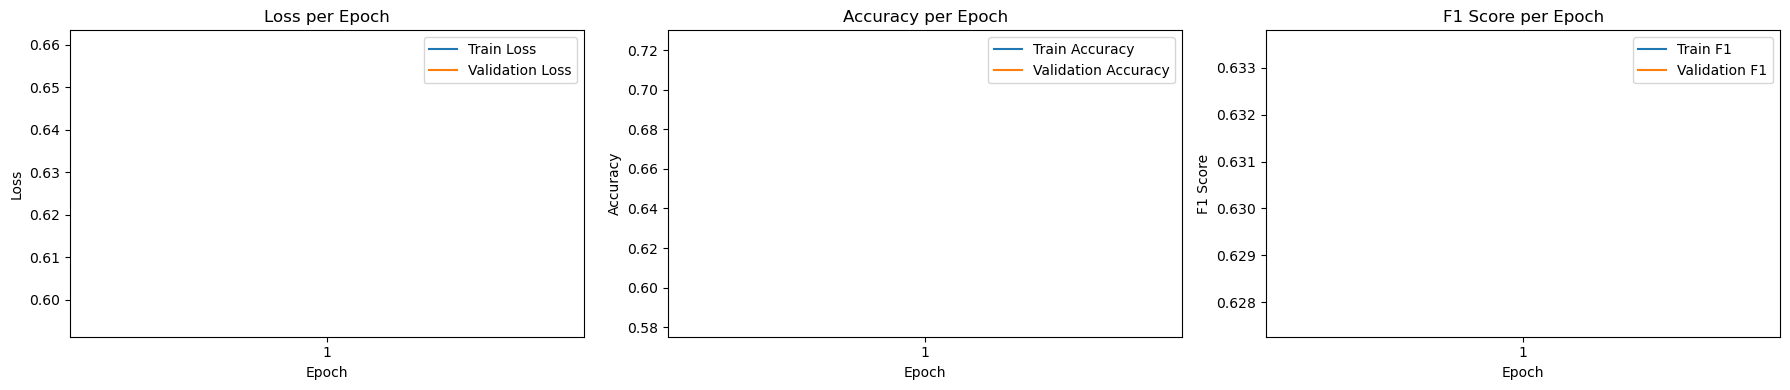

Epoch 1/50: T_Loss 0.6601, T_Acc 0.5822, T_F1 0.6276 | V_Loss 0.5945, V_Acc 0.7230, V_F1 0.6335 | ET


KeyboardInterrupt: 

In [5]:
# Training of Boolean Model

train_labels = train_labels_bol[:,property_index]
test_labels = test_labels_bol[:,property_index]
train_dataset = TensorDataset(train_traces[:n],train_labels[:n])
test_dataset = TensorDataset(test_traces[:n], test_labels[:n])

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



class AttentionBol(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionBol, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask):
        # lstm_out: (batch, seq_len, hidden_dim)
        scores = self.attn(lstm_out).squeeze(-1)  # (batch, seq_len)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(scores, dim=1).unsqueeze(1)  # (batch, 1, seq_len)
        weighted_sum = torch.bmm(attn_weights, lstm_out).squeeze(1)  # (batch, hidden_dim)
        return weighted_sum

# Define the model integrating embedding, time transformation, bidirectional LSTM, and attention
class TraceClassifierBol(nn.Module):
    def __init__(self, vocab_size, embed_dim, lstm_hidden):
        super(TraceClassifierBol, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.time_linear = nn.Linear(1, 8)
        # LSTM input: concatenation of embedding and time features
        self.lstm = nn.LSTM(embed_dim + 8, lstm_hidden, batch_first=True, bidirectional=True)
        self.attention = AttentionBol(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch, seq_len, 2) --> 1: activity, 2: time delta
        act = x[:, :, 0].long()
        time = x[:, :, 1].unsqueeze(-1)
        emb = self.embedding(act)  # (batch, seq_len, embed_dim)
        time_feat = self.time_linear(time)  # (batch, seq_len, 8)
        combined = torch.cat([emb, time_feat], dim=2)  # (batch, seq_len, embed_dim+8)
        lstm_out, _ = self.lstm(combined)  # (batch, seq_len, lstm_hidden*2)
        # Create a mask to ignore padding (0 for activity 0)
        mask = (act != 0).float()
        attn_out = self.attention(lstm_out, mask)  # (batch, lstm_hidden*2)
        out = self.fc(attn_out)
        return self.sigmoid(out).squeeze()

vocab_size = max(act2idx.values()) + 1
model = TraceClassifierBol(vocab_size, embed_dim=16, lstm_hidden=64)
model.to(device)

# Compute class weights on the training set
# train_labels is a tensor of shape (N,)
class_counts = torch.tensor([(train_labels == 0).sum(), (train_labels == 1).sum()], dtype=torch.float32)
# Each class weight is balanced relative to the dataset size
class_weights = (1.0 / class_counts) * (len(train_labels) / 2.0)
class_weights = class_weights.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50  
progress_bar_ncols = 100

train_losses = []
train_accs = []
train_f1s = []
val_losses = []
val_accs = []
val_f1s = []

epoch_bar = trange(epochs, ncols=progress_bar_ncols)
start_train_time = time.time()
epoch_times = []

for epoch in epoch_bar:
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_train_preds = []
    all_train_true = []
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        # Create a tensor of weights for the batch: if label is 1, use weight for 1, otherwise for 0
        weights = torch.where(batch_y == 1, class_weights[1], class_weights[0])
        loss = nn.functional.binary_cross_entropy(outputs, batch_y, weight=weights)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        predicted = (outputs > 0.5).float()
        correct += (predicted == batch_y).sum().item()
        total += torch.numel(batch_y)
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_true.extend(batch_y.cpu().numpy())
    
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_train_true, all_train_preds, average='binary')
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    train_f1s.append(epoch_f1)
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_val_preds = []
    all_val_true = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            # Compute weights for the batch
            weights = torch.where(batch_y == 1, class_weights[1], class_weights[0])
            loss = nn.functional.binary_cross_entropy(outputs, batch_y, weight=weights)
            val_loss += loss.item() * batch_x.size(0)
            predicted = (outputs > 0.5).float()
            val_correct += (predicted == batch_y).sum().item()
            val_total += torch.numel(batch_y)
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_true.extend(batch_y.cpu().numpy())
    val_loss /= len(test_dataset)
    val_acc = val_correct / val_total
    val_f1 = f1_score(all_val_true, all_val_preds, average='binary')
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    
    epoch_times.append(time.time() - start_train_time)
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    remaining_time = avg_epoch_time * (epochs - (epoch + 1))
    
    epoch_bar.set_description(
        f"Epoch {epoch+1}/{epochs}: T_Loss {epoch_loss:.4f}, T_Acc {epoch_acc:.4f}, T_F1 {epoch_f1:.4f} | "
        f"V_Loss {val_loss:.4f}, V_Acc {val_acc:.4f}, V_F1 {val_f1:.4f} | ETA: {remaining_time:.2f} sec"
    )
    
    clear_output(wait=True)
    epochs_range = range(1, epoch+2)
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 4))
    ax1.plot(epochs_range, train_losses, label="Train Loss")
    ax1.plot(epochs_range, val_losses, label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xticks(list(epochs_range))
    ax1.legend()
    
    ax2.plot(epochs_range, train_accs, label="Train Accuracy")
    ax2.plot(epochs_range, val_accs, label="Validation Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy per Epoch")
    ax2.set_xticks(list(epochs_range))
    ax2.legend()
    
    ax3.plot(epochs_range, train_f1s, label="Train F1")
    ax3.plot(epochs_range, val_f1s, label="Validation F1")
    ax3.set_xlabel("Epoch")
    ax3.set_ylabel("F1 Score")
    ax3.set_title("F1 Score per Epoch")
    ax3.set_xticks(list(epochs_range))
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

total_train_time = time.time() - start_train_time
print(f"\nTraining completed in {total_train_time:.2f} seconds.")

## Evaluating LSTM with Boolean semantics

In [8]:
# Eval of boolean model
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
all_test_preds = []
all_test_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        weights = torch.where(batch_y == 1, class_weights[1], class_weights[0])
        loss = nn.functional.binary_cross_entropy(outputs, batch_y, weight=weights)
        test_loss += loss.item() * batch_x.size(0)
        predicted = (outputs > 0.5).float()
        test_correct += (predicted == batch_y).sum().item()
        test_total += torch.numel(batch_y)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_true.extend(batch_y.cpu().numpy())

test_loss /= len(test_dataset)
test_acc = test_correct / test_total
test_f1 = f1_score(all_test_true, all_test_preds, average='binary')
print(f"\nTest Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")

all_test_true_np = np.array(all_test_true)
all_test_preds_np = np.array(all_test_preds)
correct_0 = np.sum((all_test_true_np == 0) & (all_test_preds_np == 0))
correct_1 = np.sum((all_test_true_np == 1) & (all_test_preds_np == 1))
total_0 = np.sum(all_test_true_np == 0)
total_1 = np.sum(all_test_true_np == 1)
print(f"Class 0: Correct predictions {correct_0} out of {total_0}")
print(f"Class 1: Correct predictions {correct_1} out of {total_1}")

torch.save(model.state_dict(), f'remove_partial/trace_classifier_bol_prop_{property_index}.pt')


Test Loss: 0.9084, Test Accuracy: 0.5303, Test F1: 0.6196
Class 0: Correct predictions 8250 out of 28310
Class 1: Correct predictions 21355 out of 27518


## Training LSTM with time-robustness semantics

In [4]:
# normalize data 
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler


# Step 1: Normalize using StandardScaler (zero mean, unit variance)
scaler = StandardScaler()
normalized_data_train = scaler.fit_transform(train_labels_rob[:,property_index].reshape(-1,1))
normalized_data_test = scaler.transform(test_labels_rob[:,property_index].reshape(-1,1))

# Step 2: Convert to PyTorch tensor
train_labels_rob_norm_prop = torch.tensor(normalized_data_train, dtype=torch.float32)
test_labels_rob_norm_prop = torch.tensor(normalized_data_test, dtype=torch.float32)

In [5]:
import pickle

with open(f"remove_partial/scaler_rob_prop_{property_index}.pickle", "wb") as f:
    pickle.dump(scaler, f)

In [6]:
# Training of Boolean Model

train_labels = train_labels_rob_norm_prop
test_labels = test_labels_rob_norm_prop
train_dataset = TensorDataset(train_traces[:n],train_labels[:n])
test_dataset = TensorDataset(test_traces[:n], test_labels[:n])


batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class AttentionRob(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionRob, self).__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out, mask):
        scores = self.attn(lstm_out).squeeze(-1)
        scores = scores.masked_fill(mask == 0, float('-inf'))
        attn_weights = torch.softmax(scores, dim=1).unsqueeze(1)
        weighted_sum = torch.bmm(attn_weights, lstm_out).squeeze(1)
        return weighted_sum

# Define the model integrating embedding, time transformation, bidirectional LSTM, and attention
class TraceClassifierRob(nn.Module):
    def __init__(self, vocab_size, embed_dim, lstm_hidden):
        super(TraceClassifierRob, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.time_linear = nn.Linear(1, 8)
        self.lstm = nn.LSTM(embed_dim + 8, lstm_hidden, batch_first=True, bidirectional=True)
        self.attention = AttentionRob(lstm_hidden * 2)
        self.fc = nn.Linear(lstm_hidden * 2, 1)

    def forward(self, x):
        # x: (batch, seq_len, 2) --> 1: activity, 2: time delta
        act = x[:, :, 0].long()
        time = x[:, :, 1].unsqueeze(-1)
        emb = self.embedding(act)  # (batch, seq_len, embed_dim)
        time_feat = self.time_linear(time)  # (batch, seq_len, 8)
        combined = torch.cat([emb, time_feat], dim=2)  # (batch, seq_len, embed_dim+8)
        lstm_out, _ = self.lstm(combined)  # (batch, seq_len, lstm_hidden*2)
        # Create a mask to ignore padding (0 for activity 0)
        mask = (act != 0).float()
        attn_out = self.attention(lstm_out, mask)  # (batch, lstm_hidden*2)
        output = self.fc(attn_out)
        return output

vocab_size = max(act2idx.values()) + 1
model = TraceClassifierRob(vocab_size, embed_dim=16, lstm_hidden=64)
model.to(device)

optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50  
progress_bar_ncols = 100

train_losses = []
train_accs = []
train_f1s = []
val_losses = []
val_accs = []
val_f1s = []

epoch_bar = trange(epochs, ncols=progress_bar_ncols)
start_train_time = time.time()
epoch_times = []
loss_fn = nn.MSELoss()  # Loss function

for epoch in epoch_bar:
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_train_preds = []
    all_train_true = []
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        # Create a tensor of weights for the batch: if label is 1, use weight for 1, otherwise for 0
        # weights = torch.where(batch_y == 1, class_weights[1], class_weights[0])
        loss = loss_fn(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)
        #predicted = (outputs > 0.5).float()
        #correct += (predicted == batch_y).sum().item()
        #total += torch.numel(batch_y)
        #all_train_preds.extend(predicted.cpu().numpy())
        #all_train_true.extend(batch_y.cpu().numpy())
    
    epoch_loss = running_loss / len(train_dataset)
    #epoch_acc = correct / total
    #epoch_f1 = f1_score(all_train_true, all_train_preds, average='binary')
    train_losses.append(epoch_loss)
    #train_accs.append(epoch_acc)
    #train_f1s.append(epoch_f1)
    
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_val_preds = []
    all_val_true = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss =loss_fn(outputs, batch_y)
            val_loss += loss.item() * batch_x.size(0)
            #predicted = (outputs > 0.5).float()
            #val_correct += (predicted == batch_y).sum().item()
            #val_total += torch.numel(batch_y)
            #all_val_preds.extend(predicted.cpu().numpy())
            #all_val_true.extend(batch_y.cpu().numpy())
    val_loss /= len(test_dataset)
    #val_acc = val_correct / val_total
    #val_f1 = f1_score(all_val_true, all_val_preds, average='binary')
    val_losses.append(val_loss)
    #val_accs.append(val_acc)
    #val_f1s.append(val_f1)
    
    epoch_times.append(time.time() - start_train_time)
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    remaining_time = avg_epoch_time * (epochs - (epoch + 1))
    
    epoch_bar.set_description(
        f"Epoch {epoch+1}/{epochs}: T_Loss {epoch_loss:.4f}, V_Loss {val_loss:.4f}|"#, T_Acc {epoch_acc:.4f}, T_F1 {epoch_f1:.4f} | "
        #f"V_Loss {val_loss:.4f}, V_Acc {val_acc:.4f}, V_F1 {val_f1:.4f} | ETA: {remaining_time:.2f} sec"
    )
    
    clear_output(wait=True)
    epochs_range = range(1, epoch+2)
    fig, ax1 = plt.subplots(1, 1, figsize=(18, 4))
    ax1.plot(epochs_range, train_losses, label="Train Loss")
    ax1.plot(epochs_range, val_losses, label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss per Epoch")
    ax1.set_xticks(list(epochs_range))
    ax1.legend()
    
    plt.tight_layout()
    plt.show()

total_train_time = time.time() - start_train_time
print(f"\nTraining completed in {total_train_time:.2f} seconds.")

  0%|                                                                        | 0/50 [00:15<?, ?it/s]

KeyboardInterrupt



## Evaluating LSTM with time-robustness semantics

In [20]:
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0
all_test_preds = []
all_test_true = []
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = loss_fn(outputs, batch_y)
        test_loss += loss.item() * batch_x.size(0)
        test_total += torch.numel(batch_y)
test_loss /= len(test_dataset)

print(f"\nTest Loss: {test_loss:.4f}")
torch.save(model.state_dict(), f'remove_partial/trace_classifier_rob_prop_{property_index}.pt')


Test Loss: 1.4079


====================== END ================

# Test

Selected trace index: 27918, Real label: 0

Sequence of events with their actual times (ignoring padding):
Event 1: A_Create Application, Time: 0.00 sec (0h 0m 0s)
Event 2: A_Submitted, Time: 0.04 sec (0h 0m 0s)
Event 3: W_Handle leads, Time: 0.29 sec (0h 0m 0s)
Event 4: W_Complete application, Time: 48.10 sec (0h 0m 48s)
Event 5: A_Concept, Time: 48.11 sec (0h 0m 48s)
Event 6: W_Complete application, Time: 54286.86 sec (15h 4m 46s)
Event 7: A_Accepted, Time: 63041.97 sec (17h 30m 41s)

Total case duration: 63041.97 sec (17h 30m 41s)

Predictions at each time point:
At 0.0 min: events = ['A_Create Application'], prediction = 0.0002
At 1.0 min: events = ['A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Complete application', 'A_Concept'], prediction = 0.0233
At 2.0 min: events = ['A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Complete application', 'A_Concept'], prediction = 0.0096
At 3.0 min: events = ['A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_

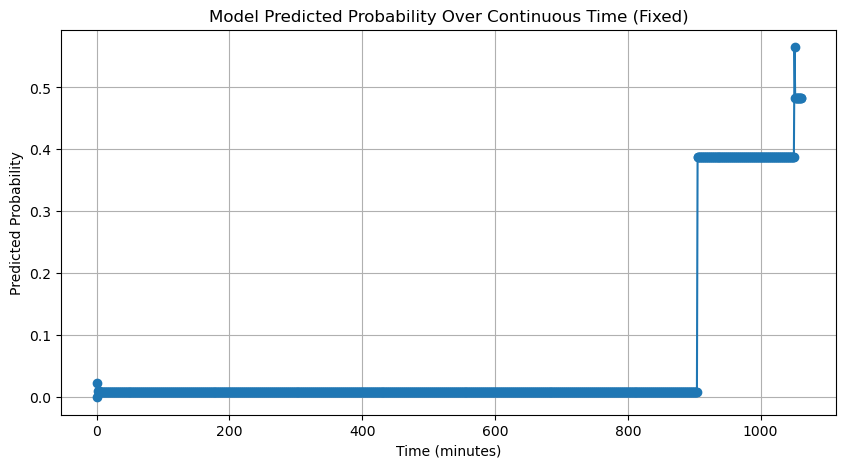

In [6]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

# Creazione del mapping inverso da indice ad attività
idx2act = {v: k for k, v in act2idx.items()}

# Selezione casuale di una trace dal test_dataset con durata >= 5 minuti
min_duration = 300  # 5 minuti

selected_trace = None
while True:
    rand_idx = random.randint(0, len(test_dataset) - 1)
    trace, true_label = test_dataset[rand_idx]
    deltas = trace[:, 1].cpu().numpy()
    cumulative_times = np.cumsum(deltas)
    cumulative_times[0] = 0.0
    actual_length = int((trace[:, 0] != 0).sum().item())
    total_duration = cumulative_times[actual_length - 1]
    if actual_length >= 2 and total_duration >= min_duration:
        selected_trace = trace
        selected_true_label = true_label
        selected_cumulative_times = cumulative_times
        break

print(f"Selected trace index: {rand_idx}, Real label: {int(selected_true_label.item())}")

print("\nSequence of events with their actual times (ignoring padding):")
for i in range(actual_length):
    act_idx = int(selected_trace[i, 0].item())
    event_time = selected_cumulative_times[i]
    act_name = idx2act.get(act_idx, f"Activity {act_idx}")
    hrs = int(event_time // 3600)
    mins = int((event_time % 3600) // 60)
    secs = int(event_time % 60)
    print(f"Event {i+1}: {act_name}, Time: {event_time:.2f} sec ({hrs}h {mins}m {secs}s)")

print(f"\nTotal case duration: {total_duration:.2f} sec ({int(total_duration//3600)}h {int((total_duration%3600)//60)}m {int(total_duration%60)}s)")

# Predizioni continue nel tempo
max_T = total_duration + 600
time_points = np.arange(0, max_T + 60, 60)
predictions = []

# Estrazione del timestamp per l'evento A_Submitted
idx_submitted = next(
    (i for i, idx in enumerate(selected_trace[:, 0].tolist())
     if idx != 0 and idx2act[int(idx)] == 'A_Submitted'),
    None
)
submitted_time = selected_cumulative_times[idx_submitted] if idx_submitted is not None else 0.0

o_sent_seen = False  # Indica se l'evento O_Sent è stato osservato entro 24h
final_pred = None    # Predizione finale fissata a 0 o 1

print("\nPredictions at each time point:")
for T in time_points:
    prefix_length = np.searchsorted(selected_cumulative_times[:actual_length], T, side='right')
    prefix_length = max(prefix_length, 1)

    if T <= total_duration:
        prefix_trace = selected_trace[:prefix_length].clone()
        if prefix_length > 1:
            prefix_trace[-1, 1] = T - selected_cumulative_times[prefix_length - 2]
        else:
            prefix_trace[-1, 1] = T
    else:
        time_since_last_event = T - total_duration
        dummy_event = torch.tensor([[0, time_since_last_event]], dtype=torch.float32)
        prefix_trace = torch.cat([selected_trace[:actual_length], dummy_event], dim=0)

    cumulative_time_since_submitted = max(0, T - submitted_time)
    prefix_trace_input = prefix_trace.unsqueeze(0).to(device)

    # Logica per fissare la predizione se l'evento O_Sent è stato osservato entro 24 ore
    if not o_sent_seen:
        for i, act_idx in enumerate(prefix_trace[:, 0].tolist()):
            if act_idx != 0 and idx2act[int(act_idx)] == 'O_Sent' and cumulative_time_since_submitted <= 86400:
                final_pred = 1.0
                o_sent_seen = True
                break
        if cumulative_time_since_submitted > 86400 and not o_sent_seen:
            final_pred = 0.0

    with torch.no_grad():
        if final_pred is not None:
            pred_prefix = final_pred  # Predizione fissa se già determinata
        else:
            # Passa il prefisso direttamente al modello tramite il forward, che gestisce embedding e trasformazione temporale
            pred_prefix = model(prefix_trace_input).item()

    predictions.append(pred_prefix)
    activities_in_prefix = [
        idx2act[int(prefix_trace[i, 0].item())]
        for i in range(prefix_trace.shape[0])
        if prefix_trace[i, 0].item() != 0
    ]
    print(f"At {T/60:.1f} min: events = {activities_in_prefix}, prediction = {pred_prefix:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(time_points / 60, predictions, marker='o', linestyle='-')
plt.xlabel("Time (minutes)")
plt.ylabel("Predicted Probability")
plt.title("Model Predicted Probability Over Continuous Time (Fixed)")
plt.grid(True)
plt.show()